<a href="https://colab.research.google.com/github/ALIA-HAIDER/CodeScope/blob/main/codeScope2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls /content/drive/MyDrive/MiniProject_CodeScope

jm1.zip  Test_data.zip	Train_data.zip


In [3]:
!cp /content/drive/MyDrive/MiniProject_CodeScope/jm1.zip /content/

In [4]:
!unzip /content/jm1.zip

Archive:  /content/jm1.zip
replace jm1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
!ls

drive  jm1.csv	jm1.zip  sample_data


In [6]:
import pandas as pd
import numpy as np


In [7]:
train=pd.read_csv('jm1.csv')

In [8]:
train.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loc                10885 non-null  float64
 1   v(g)               10885 non-null  float64
 2   ev(g)              10885 non-null  float64
 3   iv(g)              10885 non-null  float64
 4   n                  10885 non-null  float64
 5   v                  10885 non-null  float64
 6   l                  10885 non-null  float64
 7   d                  10885 non-null  float64
 8   i                  10885 non-null  float64
 9   e                  10885 non-null  float64
 10  b                  10885 non-null  float64
 11  t                  10885 non-null  float64
 12  lOCode             10885 non-null  int64  
 13  lOComment          10885 non-null  int64  
 14  lOBlank            10885 non-null  int64  
 15  locCodeAndComment  10885 non-null  int64  
 16  uniq_Op            108

In [10]:
train.isnull().sum()

,0
loc,0
v(g),0
ev(g),0
iv(g),0
n,0
v,0
l,0
d,0
i,0
e,0


Creating adiitional Target variable

In [11]:
# 1 -> Complexity level
def complexity_level(x):
    if x < 5:
        return 0
    elif x < 10:
        return 1
    else:
        return 2

train["complexity_level"] = train["v(g)"].apply(complexity_level)


In [12]:
# 2 -> Maintainability score
# 171 - 5.2 * ln(Halstead Volume) - 0.23 * Cyclomatic Complexity - 16.2 * ln(LOC)
train["maintainability_score"] = (
    171 - 5.2 * np.log(train["v"]) - 0.23 * train["v(g)"] - 16.2 * np.log(train["loc"])
)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
# 3 -> Code Smell Risk
# High complexity + large LOC = smell
train["code_smell_risk"] = ((train["v(g)"] > 10) & (train["loc"] > 200)).astype(int)



In [14]:
# 4 -> Technical Debt
# Technical debt = Cyclomatic Complexity + Halstead Effort * 0.001 + LOC
train["technical_debt"] = train["v(g)"] + train["e"] * 0.001 + train["loc"]


In [15]:
# Check new columns
print(train.columns)

Index(['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't',
       'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op',
       'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects',
       'complexity_level', 'maintainability_score', 'code_smell_risk',
       'technical_debt'],
      dtype='object')


In [16]:
train['defects']=train['defects'].map({True:1 ,False:0})
cols_to_convert = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']

for col in cols_to_convert:
    train[col] = pd.to_numeric(train[col], errors='coerce')

correlation checking


In [17]:
corr_matrix=train.corr().abs()
print(corr_matrix)

                            loc      v(g)     ev(g)     iv(g)         n  \
loc                    1.000000  0.817757  0.517551  0.784057  0.881795   
v(g)                   0.817757  1.000000  0.701710  0.859590  0.730781   
ev(g)                  0.517551  0.701710  1.000000  0.639574  0.465992   
iv(g)                  0.784057  0.859590  0.639574  1.000000  0.702415   
n                      0.881795  0.730781  0.465992  0.702415  1.000000   
v                      0.900293  0.759881  0.445902  0.743193  0.984276   
l                      0.286587  0.252902  0.233982  0.197736  0.240749   
d                      0.689543  0.669057  0.434009  0.575369  0.808113   
i                      0.499946  0.303031  0.213211  0.309717  0.651209   
e                      0.750564  0.709501  0.315538  0.757702  0.716536   
b                      0.899965  0.759635  0.445693  0.743013  0.983938   
t                      0.750564  0.709501  0.315538  0.757702  0.716536   
lOCode                 0.

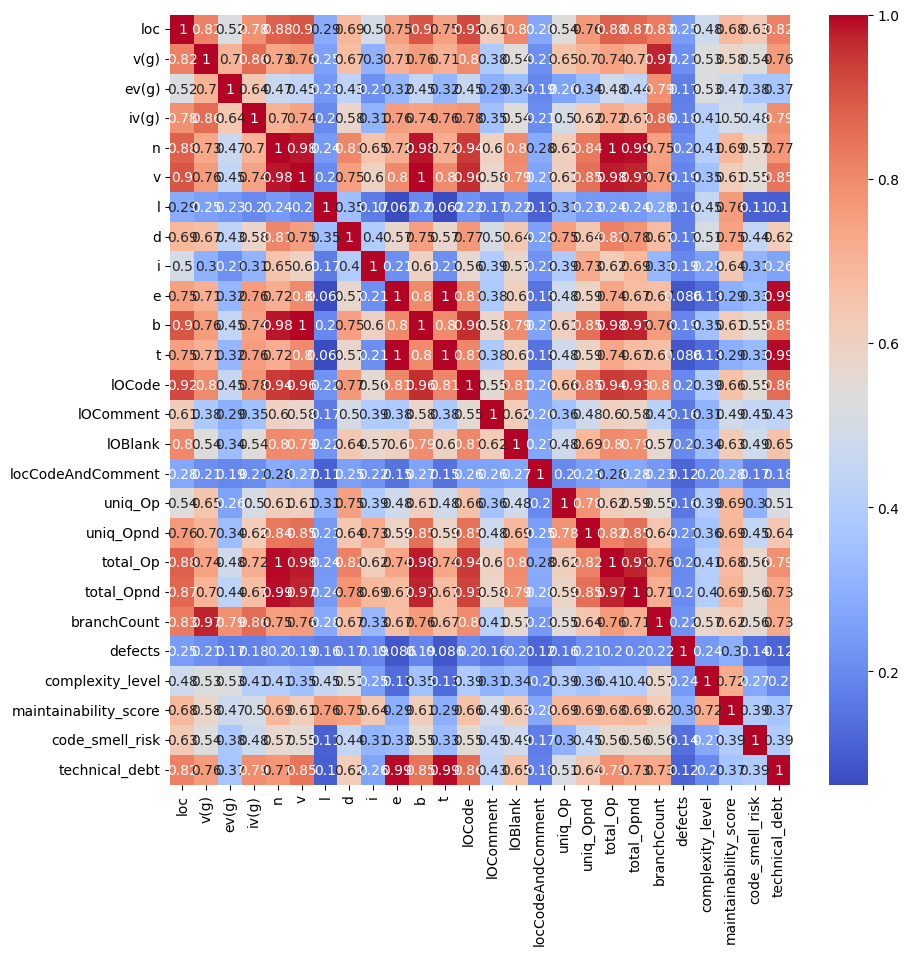

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.show()

In [19]:
# removing highly correlated features as this correlation if feature to feature
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
protected_columns=['complexity_level','maintainability_score','techincal_debt']


to_drop=[column for column in upper.columns if any(upper[column]>0.85) and column not in protected_columns]
train=train.drop(columns=to_drop)


In [20]:
print(train.columns)

Index(['loc', 'v(g)', 'ev(g)', 'l', 'd', 'i', 'e', 'lOComment', 'lOBlank',
       'locCodeAndComment', 'uniq_Op', 'defects', 'complexity_level',
       'maintainability_score', 'code_smell_risk'],
      dtype='object')


Seperating Feature and Target

In [21]:
from sklearn.model_selection import train_test_split

x=train.drop(columns=["defects"],axis=1)
y=train["defects"]

x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)


In [33]:
# Replace infinity with NaN
x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_val = x_val.replace([np.inf, -np.inf], np.nan)

# Fill NaN values (median works best for code metrics)
x_train = x_train.fillna(x_train.median())
x_val = x_val.fillna(x_train.median())

# For target
y_train = y_train.fillna(y_train.median())
y_val = y_val.fillna(y_train.median())

x_train_orig=x_train.copy()
x_val_orig=x_val.copy()

Normalize Data

In [34]:
targets = [ 'maintainability_score']
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
features = [col for col in numeric_cols if col not in targets and col !='defects']

In [35]:
skew_values = train[features].skew().sort_values(ascending=False)
print(skew_values)

e                    46.212151
locCodeAndComment    22.306581
v(g)                 15.218085
loc                  14.826236
uniq_Op              14.567006
lOBlank              13.553075
lOComment            11.394199
ev(g)                 8.185657
code_smell_risk       6.770909
d                     6.017683
i                     5.152754
l                     1.920659
complexity_level      0.954951
dtype: float64


In [36]:
from sklearn.preprocessing import PowerTransformer, StandardScaler

x_train_bug = x_train_orig.copy()
x_val_bug = x_val_orig.copy()
y_train_bug = y_train.copy()
y_val_bug = y_val.copy()


# Apply Yeo-Johnson (handles skew)
pt = PowerTransformer(method='yeo-johnson')
x_train_bug[features] = pt.fit_transform(x_train_bug[features])
x_val_bug[features] = pt.transform(x_val_bug[features])


#  Scale to mean=0, std=1
scaler = StandardScaler()
x_train_bug[features] = scaler.fit_transform(x_train_bug[features])
x_val_bug[features] = scaler.transform(x_val_bug[features])


In [37]:
skew_values = x_train_bug[features].skew().sort_values(ascending=False)
print(skew_values)

code_smell_risk      6.622246
locCodeAndComment    2.369605
ev(g)                0.852233
lOComment            0.833450
complexity_level     0.517239
l                    0.340700
uniq_Op              0.183872
v(g)                 0.133417
lOBlank              0.087337
i                    0.042746
loc                  0.021888
d                   -0.020126
e                   -0.040295
dtype: float64


In [38]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_bug=scaler.fit_transform(x_train_bug)
x_val_bug=scaler.transform(x_val_bug)


Model Training


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, r2_score

In [40]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

Bug Risk Model

In [44]:
bug_model=RandomForestClassifier(
     n_estimators=300,
    max_depth=None,  # allow full growth
    class_weight='balanced',  # auto-weight classes
    random_state=42,
    n_jobs=-1
)

bug_model.fit(x_train_bug,y_train_bug)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [46]:
bug_pred=bug_model.predict(x_val_bug)

In [47]:
print("Bug Risk Accuracy:", accuracy_score(y_val_bug, bug_pred))
print(classification_report(y_val_bug, bug_pred))

Bug Risk Accuracy: 0.8144235186035829
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      1758
           1       0.54      0.22      0.32       419

    accuracy                           0.81      2177
   macro avg       0.69      0.59      0.60      2177
weighted avg       0.78      0.81      0.78      2177



Mainatainability score


In [ ]:
features1 = [col for col in numeric_cols if col not in ['maintainability_score']]
pt = PowerTransformer(method='yeo-johnson')
x_train[features] = pt.fit_transform(x_train[features])
x_val[features] = pt.transform(x_val[features])

scaler = StandardScaler()
x_train[features] = scaler.fit_transform(x_train[features])
x_val[features] = scaler.transform(x_val[features])